# 01 Baseline PM2.5 Model V4 - Horizon-Specific Models

V4 improvements:
- Add traffic features (avg_traffic_volume, congestion_index)
- Add temporal features (is_weekend, month_sin/cos)
- Add data quality score
- Horizon-specific feature sets for LinearRegression
- Remove Ridge (redundant with alpha=1.0)

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from datetime import datetime
from tqdm import tqdm
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print(f"Starting V4 analysis: {datetime.now()}")

Starting V4 analysis: 2025-09-02 01:15:41.512759


## 1. Load and Analyze Coverage

In [2]:
DATA_PATH = '/Users/vojtech/Code/Bard89/smoglens-data/pm25_enriched_2023_2025_v4_20250830_222050.csv'

print("Loading dataset...")
df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])
df = df.sort_values(['hex7_id', 'timestamp']).reset_index(drop=True)

print(f"Full dataset: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Total hexagons: {df['hex7_id'].nunique()}")
print(f"\nColumns available: {df.columns.tolist()[:20]}...")

Loading dataset...
Full dataset: (9457112, 39)
Date range: 2023-07-14 16:00:00+00:00 to 2025-07-26 05:00:00+00:00
Total hexagons: 634

Columns available: ['timestamp', 'hex7_id', 'lat', 'lon', 'pm25_ugm3_mean', 'pm25_ugm3_min', 'pm25_ugm3_max', 'pm25_ugm3_count', 'pm25_range', 'avg_traffic_volume', 'max_traffic_volume', 'avg_speed_kmh', 'congestion_index', 'unique_links', 'traffic_measurement_count', 'traffic_distance_km', 'traffic_intensity', 'temperature_c_mean', 'humidity_pct_mean', 'precipitation_mm_mean']...


In [3]:
coverage_stats = df.groupby('hex7_id').agg({
    'pm25_ugm3_mean': [
        'count',
        lambda x: x.notna().sum(),
        lambda x: x.notna().mean()
    ],
    'timestamp': ['min', 'max']
}).round(3)

coverage_stats.columns = ['total_hours', 'valid_pm25', 'coverage_ratio', 'start_date', 'end_date']
coverage_stats['duration_days'] = (coverage_stats['end_date'] - coverage_stats['start_date']).dt.days

print("\nCoverage Distribution:")
print(coverage_stats['coverage_ratio'].describe())

print(f"\nHexagons by coverage threshold:")
for threshold in [0.7, 0.8, 0.85, 0.9, 0.95]:
    count = (coverage_stats['coverage_ratio'] >= threshold).sum()
    print(f"  >= {threshold:.0%}: {count} hexagons")


Coverage Distribution:
count   634.000
mean      0.800
std       0.356
min       0.000
25%       0.911
50%       0.968
75%       0.985
max       1.000
Name: coverage_ratio, dtype: float64

Hexagons by coverage threshold:
  >= 70%: 520 hexagons
  >= 80%: 510 hexagons
  >= 85%: 500 hexagons
  >= 90%: 485 hexagons
  >= 95%: 412 hexagons


## 2. Select High Coverage Hexagons

In [4]:
COVERAGE_THRESHOLD = 0.90
MIN_DURATION_DAYS = 100

high_coverage_hexagons = coverage_stats[
    (coverage_stats['coverage_ratio'] >= COVERAGE_THRESHOLD) & 
    (coverage_stats['duration_days'] >= MIN_DURATION_DAYS)
].index.tolist()

print(f"Selected {len(high_coverage_hexagons)} hexagons with >= {COVERAGE_THRESHOLD:.0%} coverage")
print(f"and >= {MIN_DURATION_DAYS} days of data")

df_filtered = df[df['hex7_id'].isin(high_coverage_hexagons)].copy()
print(f"\nFiltered dataset: {df_filtered.shape}")
print(f"PM2.5 coverage in filtered data: {df_filtered['pm25_ugm3_mean'].notna().mean():.1%}")

Selected 485 hexagons with >= 90% coverage
and >= 100 days of data

Filtered dataset: (7320911, 39)
PM2.5 coverage in filtered data: 97.1%


## 3. Handle Missing Data and Outliers

In [5]:
pm25_cap = df_filtered['pm25_ugm3_mean'].quantile(0.999)
print(f"Capping PM2.5 at 99.9th percentile: {pm25_cap:.1f} μg/m³")
df_filtered['pm25_ugm3_mean'] = df_filtered['pm25_ugm3_mean'].clip(upper=pm25_cap)

df_filtered['pm25'] = df_filtered.groupby('hex7_id')['pm25_ugm3_mean'].transform(
    lambda x: x.interpolate(method='linear', limit=3)
)

print(f"PM2.5 missing after interpolation: {df_filtered['pm25'].isna().mean():.2%}")

df_filtered = df_filtered.dropna(subset=['pm25'])
print(f"Final dataset after removing remaining NaN: {df_filtered.shape}")

Capping PM2.5 at 99.9th percentile: 53.0 μg/m³
PM2.5 missing after interpolation: 1.09%
Final dataset after removing remaining NaN: (7241466, 40)


## 4. Create Time Series Features

In [6]:
df_filtered = df_filtered.sort_values(['hex7_id', 'timestamp']).reset_index(drop=True)

lag_hours = [1, 2, 3, 4, 5, 6, 12, 24, 48, 72, 168]
print("Creating extended lag features for long horizons...")
for lag in tqdm(lag_hours):
    df_filtered[f'lag_{lag}h'] = df_filtered.groupby('hex7_id')['pm25'].shift(lag)

print("Creating rolling statistics...")
df_filtered['rolling_mean_6h'] = df_filtered.groupby('hex7_id')['pm25'].transform(
    lambda x: x.rolling(6, min_periods=3).mean()
)
df_filtered['rolling_std_6h'] = df_filtered.groupby('hex7_id')['pm25'].transform(
    lambda x: x.rolling(6, min_periods=3).std()
)
df_filtered['rolling_mean_24h'] = df_filtered.groupby('hex7_id')['pm25'].transform(
    lambda x: x.rolling(24, min_periods=12).mean()
)
df_filtered['rolling_std_24h'] = df_filtered.groupby('hex7_id')['pm25'].transform(
    lambda x: x.rolling(24, min_periods=12).std()
)
df_filtered['rolling_mean_48h'] = df_filtered.groupby('hex7_id')['pm25'].transform(
    lambda x: x.rolling(48, min_periods=24).mean()
)

df_filtered['hour'] = df_filtered['timestamp'].dt.hour
df_filtered['day_of_week'] = df_filtered['timestamp'].dt.dayofweek
df_filtered['month'] = df_filtered['timestamp'].dt.month

df_filtered['hour_sin'] = np.sin(2 * np.pi * df_filtered['hour'] / 24)
df_filtered['hour_cos'] = np.cos(2 * np.pi * df_filtered['hour'] / 24)
df_filtered['dow_sin'] = np.sin(2 * np.pi * df_filtered['day_of_week'] / 7)
df_filtered['dow_cos'] = np.cos(2 * np.pi * df_filtered['day_of_week'] / 7)
df_filtered['month_sin'] = np.sin(2 * np.pi * df_filtered['month'] / 12)
df_filtered['month_cos'] = np.cos(2 * np.pi * df_filtered['month'] / 12)

print("Features created")

Creating extended lag features for long horizons...


100%|██████████| 11/11 [00:01<00:00,  5.96it/s]


Creating rolling statistics...
Features created


## 5. Encode Hexagons

In [7]:
le_hex = LabelEncoder()
df_filtered['hex_encoded'] = le_hex.fit_transform(df_filtered['hex7_id'])

print(f"Encoded {len(le_hex.classes_)} hexagons")
print(f"Sample: {df_filtered['hex7_id'].iloc[0]} -> {df_filtered['hex_encoded'].iloc[0]}")

Encoded 485 hexagons
Sample: 872e0122effffff -> 0


## 6. Create Targets and Horizon-Specific Features

In [8]:
horizons = [1, 2, 3, 4, 5, 6, 12, 24]
target_cols = []

for h in horizons:
    col_name = f'target_{h}h'
    df_filtered[col_name] = df_filtered.groupby('hex7_id')['pm25'].shift(-h)
    target_cols.append(col_name)

base_lag_features = ['lag_1h', 'lag_2h', 'lag_3h', 'lag_4h', 'lag_5h', 'lag_6h']
medium_lag_features = ['lag_12h', 'lag_24h']
long_lag_features = ['lag_48h', 'lag_72h', 'lag_168h']

rolling_features = ['rolling_mean_6h', 'rolling_std_6h', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_48h']

temporal_features = ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend']

weather_features = ['temperature_c_mean', 'humidity_pct_mean', 'pressure_hpa_mean']
traffic_features = ['avg_traffic_volume', 'congestion_index']
quality_features = ['data_completeness_score']

for feat in weather_features + traffic_features:
    if feat in df_filtered.columns:
        df_filtered[feat] = df_filtered[feat].fillna(df_filtered[feat].median())

short_horizon_features = (
    base_lag_features + 
    rolling_features[:3] +
    temporal_features + 
    weather_features + 
    traffic_features +
    quality_features +
    ['hex_encoded']
)

long_horizon_features = (
    base_lag_features[:3] +
    medium_lag_features + 
    long_lag_features +
    rolling_features +
    temporal_features + 
    weather_features + 
    traffic_features +
    quality_features +
    ['hex_encoded']
)

all_features = list(set(short_horizon_features + long_horizon_features))

available_features = [f for f in all_features if f in df_filtered.columns]
print(f"Total available features: {len(available_features)}")
print(f"Short horizon features: {len([f for f in short_horizon_features if f in df_filtered.columns])}")
print(f"Long horizon features: {len([f for f in long_horizon_features if f in df_filtered.columns])}")

Total available features: 30
Short horizon features: 23
Long horizon features: 27


## 7. Train/Test Split

In [9]:
df_filtered = df_filtered.dropna(subset=available_features + target_cols)

df_filtered['year'] = df_filtered['timestamp'].dt.year

train_data = df_filtered[df_filtered['year'].isin([2023, 2024])].copy()
test_data = df_filtered[df_filtered['year'] == 2025].copy()

print(f"Train: {len(train_data):,} samples ({train_data['timestamp'].min()} to {train_data['timestamp'].max()})")
print(f"Test: {len(test_data):,} samples ({test_data['timestamp'].min()} to {test_data['timestamp'].max()})")
print(f"Train hexagons: {train_data['hex7_id'].nunique()}")
print(f"Test hexagons: {test_data['hex7_id'].nunique()}")

Train: 5,080,144 samples (2023-08-04 00:00:00+00:00 to 2024-12-31 23:00:00+00:00)
Test: 2,068,202 samples (2025-01-01 00:00:00+00:00 to 2025-07-25 03:00:00+00:00)
Train hexagons: 485
Test hexagons: 479


In [10]:
X_train_all = train_data[available_features]
X_test_all = test_data[available_features]

short_features_avail = [f for f in short_horizon_features if f in df_filtered.columns]
long_features_avail = [f for f in long_horizon_features if f in df_filtered.columns]

X_train_short = train_data[short_features_avail]
X_test_short = test_data[short_features_avail]

X_train_long = train_data[long_features_avail]
X_test_long = test_data[long_features_avail]

y_train = {}
y_test = {}

for col in target_cols:
    y_train[col] = train_data[col]
    y_test[col] = test_data[col]

print(f"X_train_all shape: {X_train_all.shape}")
print(f"X_train_short shape: {X_train_short.shape}")
print(f"X_train_long shape: {X_train_long.shape}")

X_train_all shape: (5080144, 30)
X_train_short shape: (5080144, 23)
X_train_long shape: (5080144, 27)


## 8. Train Models with Horizon-Specific Features

In [11]:
results = {}
predictions = {}

def get_numeric_features(feature_list):
    return [f for f in feature_list if f != 'hex_encoded']

def prepare_scaled_data(X_train, X_test, feature_list):
    numeric_feats = get_numeric_features(feature_list)
    X_train_numeric = X_train[numeric_feats]
    X_test_numeric = X_test[numeric_feats]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_numeric)
    X_test_scaled = scaler.transform(X_test_numeric)
    return X_train_scaled, X_test_scaled

X_train_short_scaled, X_test_short_scaled = prepare_scaled_data(X_train_short, X_test_short, short_features_avail)
X_train_long_scaled, X_test_long_scaled = prepare_scaled_data(X_train_long, X_test_long, long_features_avail)

for target_col in target_cols:
    horizon = target_col.split('_')[1]
    horizon_hours = int(horizon[:-1])
    print(f"\nTraining for {horizon} prediction...")
    
    y_tr = y_train[target_col]
    y_te = y_test[target_col]
    
    results[horizon] = {}
    predictions[horizon] = {}
    
    lag_col = f'lag_{horizon[:-1]}h' if f'lag_{horizon[:-1]}h' in X_test_all.columns else 'lag_1h'
    persistence_pred = X_test_all[lag_col].values
    persistence_mae = mean_absolute_error(y_te, persistence_pred)
    persistence_rmse = np.sqrt(mean_squared_error(y_te, persistence_pred))
    persistence_r2 = r2_score(y_te, persistence_pred)
    
    results[horizon]['Persistence'] = {
        'mae': persistence_mae, 
        'rmse': persistence_rmse,
        'r2': persistence_r2
    }
    predictions[horizon]['Persistence'] = persistence_pred
    
    if horizon_hours <= 6:
        X_train_lr = X_train_short_scaled
        X_test_lr = X_test_short_scaled
        model_type = "Short-horizon"
    else:
        X_train_lr = X_train_long_scaled
        X_test_lr = X_test_long_scaled
        model_type = "Long-horizon"
    
    lr = LinearRegression()
    lr.fit(X_train_lr, y_tr)
    lr_pred = lr.predict(X_test_lr)
    lr_mae = mean_absolute_error(y_te, lr_pred)
    lr_rmse = np.sqrt(mean_squared_error(y_te, lr_pred))
    lr_r2 = r2_score(y_te, lr_pred)
    
    results[horizon]['LinearReg'] = {
        'mae': lr_mae,
        'rmse': lr_rmse,
        'r2': lr_r2,
        'model': lr,
        'model_type': model_type
    }
    predictions[horizon]['LinearReg'] = lr_pred
    
    lgb_params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'num_leaves': 31,
        'learning_rate': 0.05,
        'feature_fraction': 0.9,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'verbose': -1,
        'n_jobs': 8,
        'random_state': 42
    }
    
    train_set = lgb.Dataset(
        X_train_all,
        label=y_tr,
        categorical_feature=['hex_encoded']
    )
    valid_set = lgb.Dataset(
        X_test_all,
        label=y_te,
        reference=train_set,
        categorical_feature=['hex_encoded']
    )
    
    lgb_model = lgb.train(
        lgb_params,
        train_set,
        num_boost_round=500,
        valid_sets=[valid_set],
        callbacks=[
            lgb.early_stopping(stopping_rounds=20),
            lgb.log_evaluation(period=0)
        ]
    )
    
    lgb_pred = lgb_model.predict(X_test_all, num_iteration=lgb_model.best_iteration)
    lgb_mae = mean_absolute_error(y_te, lgb_pred)
    lgb_rmse = np.sqrt(mean_squared_error(y_te, lgb_pred))
    lgb_r2 = r2_score(y_te, lgb_pred)
    
    results[horizon]['LightGBM'] = {
        'mae': lgb_mae,
        'rmse': lgb_rmse,
        'r2': lgb_r2,
        'model': lgb_model
    }
    predictions[horizon]['LightGBM'] = lgb_pred
    
    print(f"  Persistence: MAE={persistence_mae:.2f}, R²={persistence_r2:.3f}")
    print(f"  LinearReg ({model_type}): MAE={lr_mae:.2f}, R²={lr_r2:.3f}")
    print(f"  LightGBM:   MAE={lgb_mae:.2f}, R²={lgb_r2:.3f}")


Training for 1h prediction...
Training until validation scores don't improve for 20 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's rmse: 3.19245
  Persistence: MAE=2.63, R²=0.739
  LinearReg (Short-horizon): MAE=2.09, R²=0.844
  LightGBM:   MAE=2.18, R²=0.825

Training for 2h prediction...
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[375]	valid_0's rmse: 3.93838
  Persistence: MAE=3.35, R²=0.583
  LinearReg (Short-horizon): MAE=2.56, R²=0.763
  LightGBM:   MAE=2.67, R²=0.733

Training for 3h prediction...
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[269]	valid_0's rmse: 4.44214
  Persistence: MAE=3.87, R²=0.456
  LinearReg (Short-horizon): MAE=2.92, R²=0.696
  LightGBM:   MAE=3.02, R²=0.660

Training for 4h prediction...
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[163]	valid_0's rmse: 4.80999
  Persistence:

## 9. Performance Summary Tables

In [12]:
models = ['Persistence', 'LinearReg', 'LightGBM']
horizon_list = ['1h', '2h', '3h', '4h', '5h', '6h', '12h', '24h']

mae_table = pd.DataFrame(index=models, columns=horizon_list)
rmse_table = pd.DataFrame(index=models, columns=horizon_list)
r2_table = pd.DataFrame(index=models, columns=horizon_list)

for horizon in horizon_list:
    for model in models:
        mae_table.loc[model, horizon] = results[horizon][model]['mae']
        rmse_table.loc[model, horizon] = results[horizon][model]['rmse']
        r2_table.loc[model, horizon] = results[horizon][model]['r2']

print("\n" + "="*70)
print("MAE by Model and Horizon (μg/m³):")
print("="*70)
print(mae_table.round(2))

print("\n" + "="*70)
print("RMSE by Model and Horizon (μg/m³):")
print("="*70)
print(rmse_table.round(2))

print("\n" + "="*70)
print("R² by Model and Horizon:")
print("="*70)
print(r2_table.round(3))

print("\n" + "="*70)
print("LinearReg Model Types:")
print("="*70)
for horizon in horizon_list:
    model_type = results[horizon]['LinearReg'].get('model_type', 'Unknown')
    print(f"{horizon}: {model_type}")


MAE by Model and Horizon (μg/m³):
               1h    2h    3h    4h    5h    6h   12h   24h
Persistence 2.627 3.354 3.868 4.252 4.542 4.766 5.537 6.614
LinearReg   2.090 2.561 2.915 3.183 3.407 3.588 4.282 4.897
LightGBM    2.182 2.666 3.016 3.291 3.488 3.653 4.298 4.854

RMSE by Model and Horizon (μg/m³):
               1h    2h    3h    4h    5h    6h   12h   24h
Persistence 3.893 4.925 5.623 6.134 6.519 6.811 7.842 9.281
LinearReg   3.013 3.710 4.207 4.579 4.880 5.125 6.025 6.833
LightGBM    3.192 3.938 4.442 4.810 5.091 5.303 6.217 6.931

R² by Model and Horizon:
               1h    2h    3h    4h    5h    6h    12h    24h
Persistence 0.739 0.583 0.456 0.353 0.269 0.202 -0.058 -0.481
LinearReg   0.844 0.763 0.696 0.639 0.590 0.548  0.375  0.197
LightGBM    0.825 0.733 0.660 0.602 0.554 0.516  0.335  0.174

LinearReg Model Types:
1h: Short-horizon
2h: Short-horizon
3h: Short-horizon
4h: Short-horizon
5h: Short-horizon
6h: Short-horizon
12h: Long-horizon
24h: Long-horizon


## 10. Prediction vs True Visualizations (All Models & Horizons)

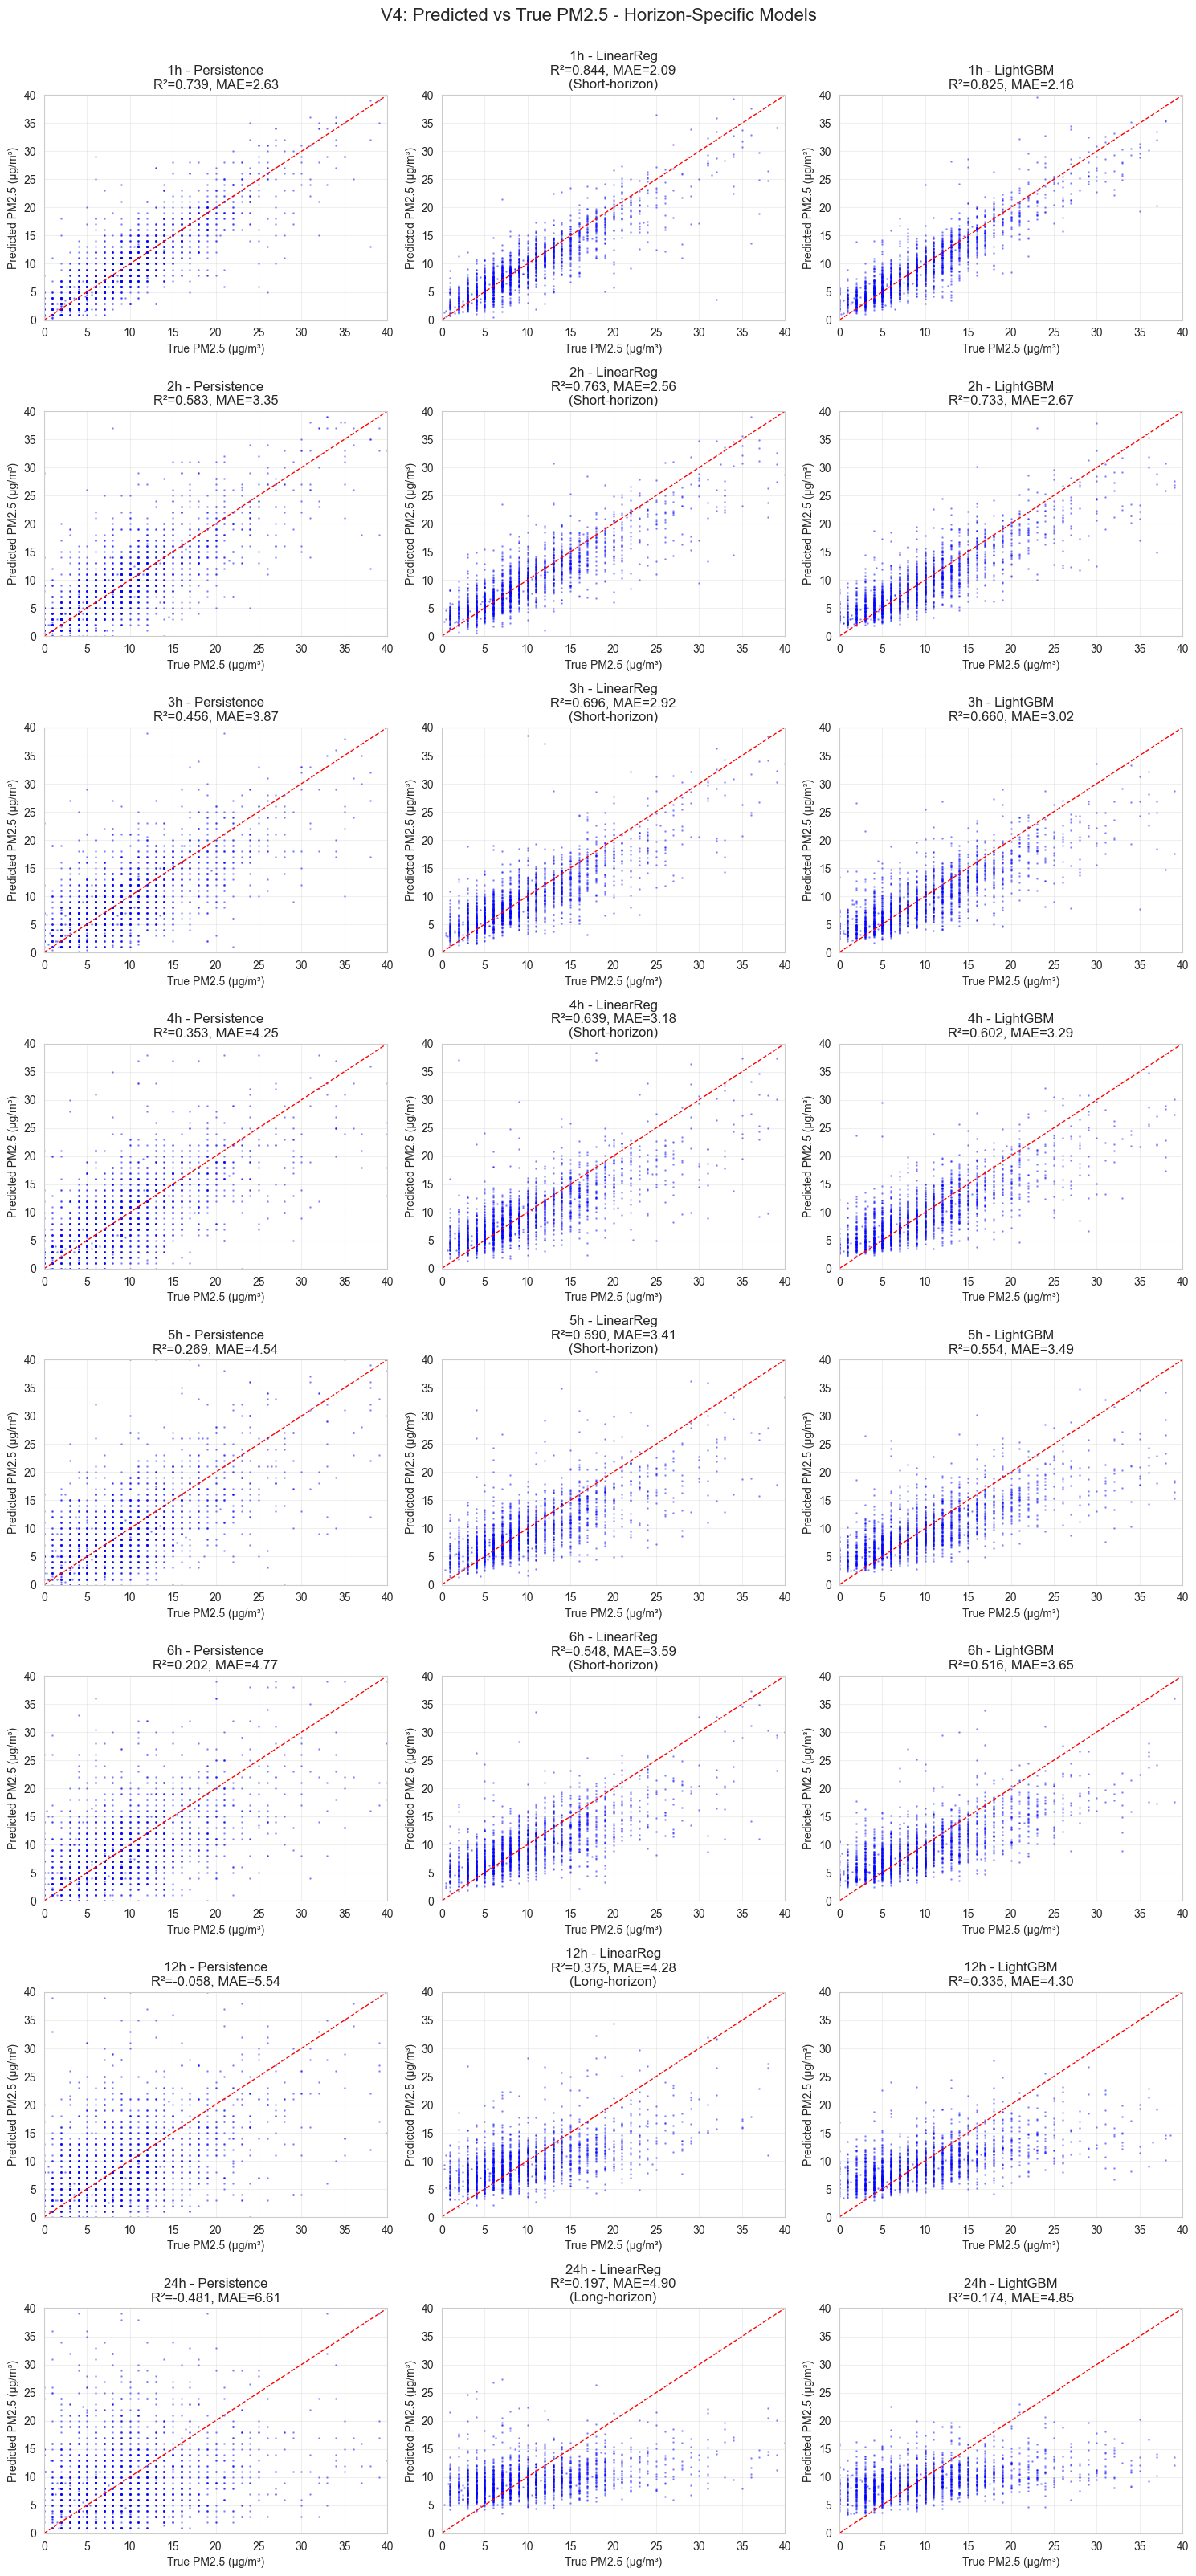

In [13]:
fig, axes = plt.subplots(8, 3, figsize=(15, 32))

for i, horizon in enumerate(horizon_list):
    y_true = y_test[f'target_{horizon}']
    
    for j, model in enumerate(models):
        ax = axes[i, j]
        y_pred = predictions[horizon][model]
        
        sample_size = min(2000, len(y_true))
        sample_idx = np.random.choice(len(y_true), sample_size, replace=False)
        
        ax.scatter(y_true.iloc[sample_idx], y_pred[sample_idx], 
                  alpha=0.3, s=1, color='blue')
        
        max_val = min(50, max(y_true.max(), np.max(y_pred)))
        ax.plot([0, max_val], [0, max_val], 'r--', lw=1)
        
        r2 = r2_table.loc[model, horizon]
        mae = mae_table.loc[model, horizon]
        
        title = f'{horizon} - {model}\nR²={r2:.3f}, MAE={mae:.2f}'
        if model == 'LinearReg':
            model_type = results[horizon]['LinearReg'].get('model_type', '')
            title += f'\n({model_type})'
        
        ax.set_title(title)
        ax.set_xlabel('True PM2.5 (μg/m³)')
        ax.set_ylabel('Predicted PM2.5 (μg/m³)')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 40)
        ax.set_ylim(0, 40)

plt.suptitle('V4: Predicted vs True PM2.5 - Horizon-Specific Models', fontsize=16, y=1.001)
plt.tight_layout()
plt.show()

## 11. Feature Importance (LightGBM - All Horizons)

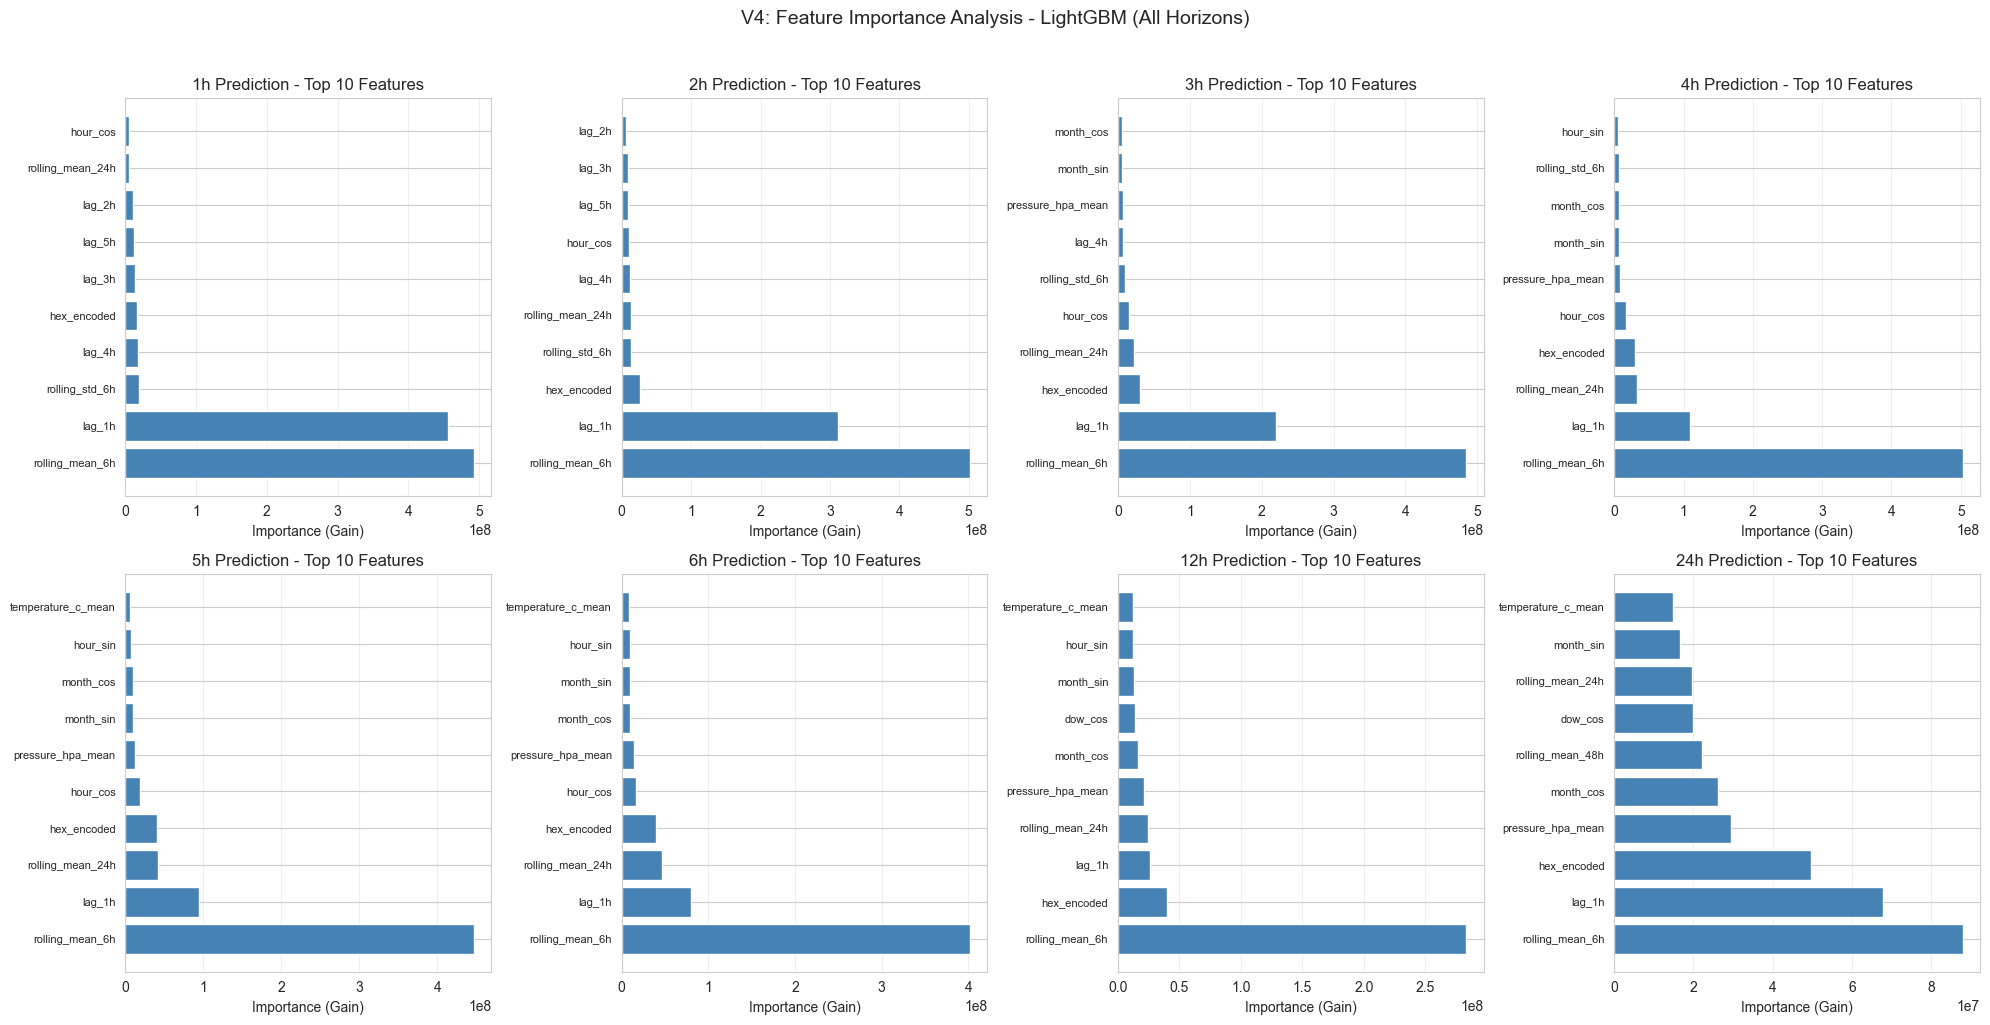

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, horizon in enumerate(horizon_list):
    if 'model' in results[horizon]['LightGBM']:
        model = results[horizon]['LightGBM']['model']
        importance = model.feature_importance(importance_type='gain')
        
        feature_imp = pd.DataFrame({
            'feature': available_features,
            'importance': importance
        }).sort_values('importance', ascending=False).head(10)
        
        ax = axes[idx]
        ax.barh(range(len(feature_imp)), feature_imp['importance'].values, color='steelblue')
        ax.set_yticks(range(len(feature_imp)))
        ax.set_yticklabels(feature_imp['feature'].values, fontsize=8)
        ax.set_xlabel('Importance (Gain)')
        ax.set_title(f'{horizon} Prediction - Top 10 Features')
        ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('V4: Feature Importance Analysis - LightGBM (All Horizons)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 12. Error Distribution Analysis

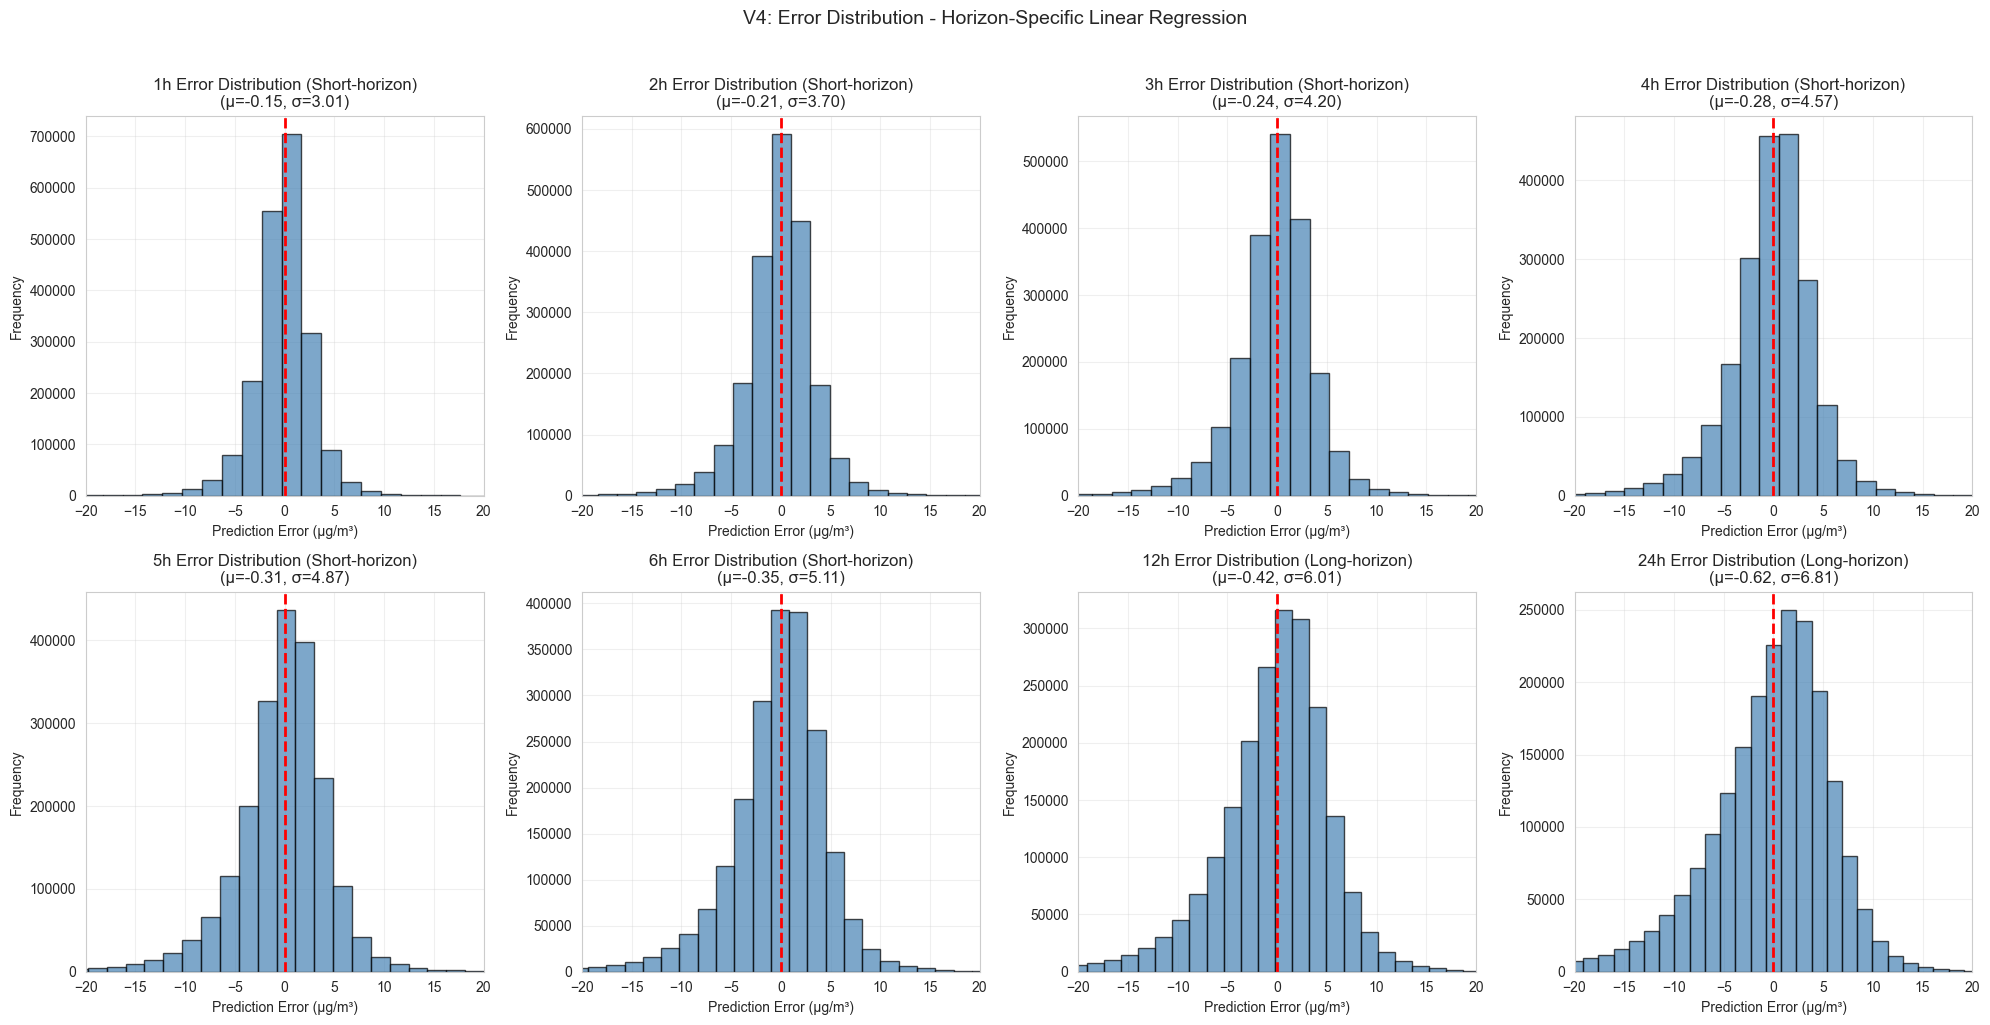

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, horizon in enumerate(horizon_list):
    ax = axes[idx]
    
    y_true = y_test[f'target_{horizon}']
    y_pred = predictions[horizon]['LinearReg']
    errors = y_pred - y_true
    
    ax.hist(errors, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Prediction Error (μg/m³)')
    ax.set_ylabel('Frequency')
    
    model_type = results[horizon]['LinearReg'].get('model_type', '')
    ax.set_title(f'{horizon} Error Distribution ({model_type})\n(μ={errors.mean():.2f}, σ={errors.std():.2f})')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-20, 20)

plt.suptitle('V4: Error Distribution - Horizon-Specific Linear Regression', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 13. Performance Comparison Visualizations

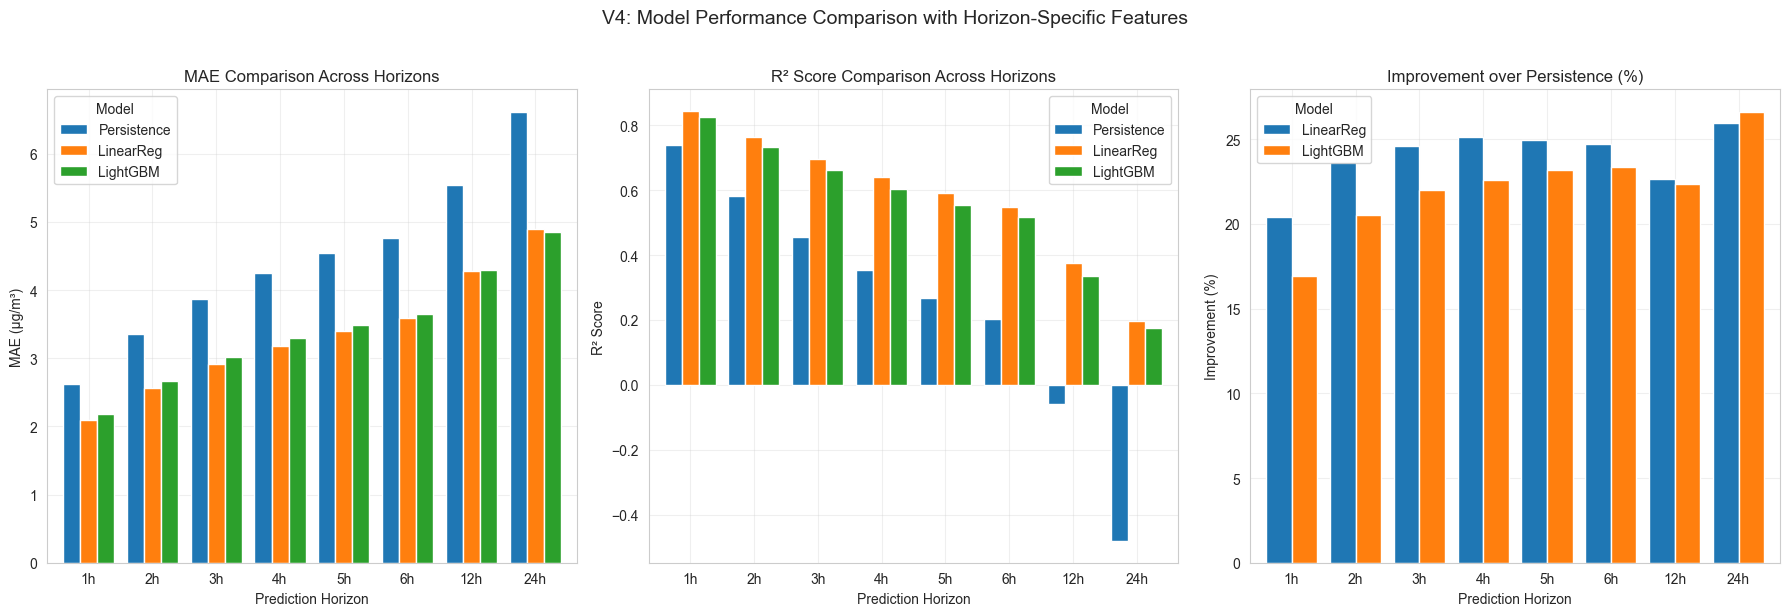

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

mae_table.T.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('MAE Comparison Across Horizons', fontsize=12)
axes[0].set_xlabel('Prediction Horizon')
axes[0].set_ylabel('MAE (μg/m³)')
axes[0].legend(title='Model', loc='upper left')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

r2_table.T.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('R² Score Comparison Across Horizons', fontsize=12)
axes[1].set_xlabel('Prediction Horizon')
axes[1].set_ylabel('R² Score')
axes[1].legend(title='Model', loc='upper right')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

improvement_data = pd.DataFrame()
for horizon in horizon_list:
    persistence_mae = mae_table.loc['Persistence', horizon]
    for model in ['LinearReg', 'LightGBM']:
        model_mae = mae_table.loc[model, horizon]
        improvement = (persistence_mae - model_mae) / persistence_mae * 100
        improvement_data.loc[model, horizon] = improvement

improvement_data.T.plot(kind='bar', ax=axes[2], width=0.8)
axes[2].set_title('Improvement over Persistence (%)', fontsize=12)
axes[2].set_xlabel('Prediction Horizon')
axes[2].set_ylabel('Improvement (%)')
axes[2].legend(title='Model')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.suptitle('V4: Model Performance Comparison with Horizon-Specific Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 14. Summary

In [17]:
print("="*70)
print("V4 MODEL TRAINING COMPLETE")
print("="*70)
print(f"\nDataset Summary:")
print(f"  Selected hexagons: {len(high_coverage_hexagons)} (>={COVERAGE_THRESHOLD:.0%} coverage)")
print(f"  Train samples: {len(X_train_all):,}")
print(f"  Test samples: {len(X_test_all):,}")
print(f"  Total features available: {len(available_features)}")
print(f"  Short-horizon features: {len(short_features_avail)}")
print(f"  Long-horizon features: {len(long_features_avail)}")

print(f"\nBest Model Performance:")
for horizon in horizon_list:
    best_r2 = -999
    best_model = None
    for model in ['LinearReg', 'LightGBM']:
        if r2_table.loc[model, horizon] > best_r2:
            best_r2 = r2_table.loc[model, horizon]
            best_model = model
    
    mae = mae_table.loc[best_model, horizon]
    print(f"  {horizon:3s}: {best_model:10s} - MAE={mae:.2f} μg/m³, R²={best_r2:.3f}")

print(f"\nV4 Improvements:")
print(f"  ✓ Added traffic features (avg_traffic_volume, congestion_index)")
print(f"  ✓ Added temporal features (is_weekend, month_sin/cos)")
print(f"  ✓ Added data quality score")
print(f"  ✓ Extended lag features for long horizons (48h, 72h, 168h)")
print(f"  ✓ Horizon-specific LinearRegression models")
print(f"  ✓ Removed redundant Ridge regression")
print(f"  ✓ Maintained high-coverage hexagon filtering")
print(f"  ✓ Kept hexagon encoding (no lat/lon)")

V4 MODEL TRAINING COMPLETE

Dataset Summary:
  Selected hexagons: 485 (>=90% coverage)
  Train samples: 5,080,144
  Test samples: 2,068,202
  Total features available: 30
  Short-horizon features: 23
  Long-horizon features: 27

Best Model Performance:
  1h : LinearReg  - MAE=2.09 μg/m³, R²=0.844
  2h : LinearReg  - MAE=2.56 μg/m³, R²=0.763
  3h : LinearReg  - MAE=2.92 μg/m³, R²=0.696
  4h : LinearReg  - MAE=3.18 μg/m³, R²=0.639
  5h : LinearReg  - MAE=3.41 μg/m³, R²=0.590
  6h : LinearReg  - MAE=3.59 μg/m³, R²=0.548
  12h: LinearReg  - MAE=4.28 μg/m³, R²=0.375
  24h: LinearReg  - MAE=4.90 μg/m³, R²=0.197

V4 Improvements:
  ✓ Added traffic features (avg_traffic_volume, congestion_index)
  ✓ Added temporal features (is_weekend, month_sin/cos)
  ✓ Added data quality score
  ✓ Extended lag features for long horizons (48h, 72h, 168h)
  ✓ Horizon-specific LinearRegression models
  ✓ Removed redundant Ridge regression
  ✓ Maintained high-coverage hexagon filtering
  ✓ Kept hexagon encoding 